## Kodexempel Neurala Nätverk

Demonstration av Neurala Nätverk samt jämförelse med klassiska Machine Learning-modeller. 

Vi kommer att titta på ett Diabetes-dataset från Scikit-learn via load_diabetes(). Det är ett litet dataset som låter oss träna modeller på några sekunder, vilket passar bra för demonstrationssyfte. 
test
Regressionsproblem för att prediktera sjukdomsprogression. 

25  → mycket låg progression
150 → medelnivå
300+ → mycket hög progression

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

import tensorflow as tf
#from tensorfow import keras

from keras.models import load_model

import keras
from keras.layers import Dense
from keras.models import Sequential
from keras.utils import to_categorical
from keras.models import load_model
from keras.callbacks import EarlyStopping

In [2]:
#### Data

In [3]:
data = load_diabetes()
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
# Split data into X and y, then train and test set 
X, y = load_diabetes(return_X_y=True, as_frame=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### EDA

In [5]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [6]:
X.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


Inga null-värden. Inga kategoriska variabler. 

Variablerna är standardiserade. ANN tränar bättre med skalade variabler. Gradienter blir mer stabila. 

#### Pre-processing

Ingen. 

#### Modelling

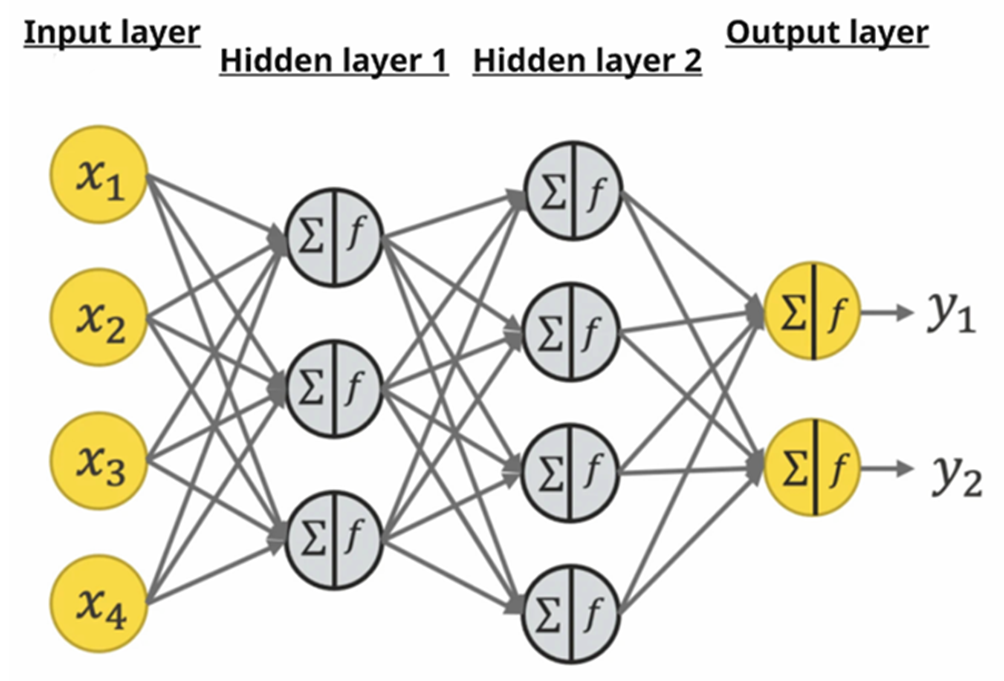

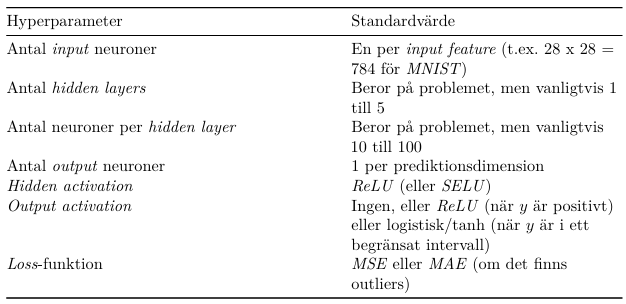

För få noder/lager: Modellen lär sig inte tillräckligt = underanpassad

För många noder/lager: Modeller kan memorera träningsdata = överanpassad

De första lagren lär sig enklare strukturer, medan påföljande lager högre upp kan kombinera dessa enklare strukturer för att modellera mer avancerade strukturer. I de dolda lagren har man rent historiskt ofta använt en pyramidstruktur för noderna. Tanken var att det finns färre avancerade strukturer än enkla strukturer och därför användes fler noder i de lägre dolda lagren. I praktiken har det visat sig att det ofta är minst lika bra att ha lika många neuroner i varje lager vilket idag är vanligt förekommande. När vi arbetar med modellering kan det vara värt att prova båda tillvägagångssätten.

I praktiken är det ofta smidigt att ha många lager och noder för att sedan använda olika regulariseringstekniker som begränsar antalet noder och lager. Intuition är att “för stora byxor kan vi alltid sy in, men för små går inte att förstora”. Det är svårt att välja rätt storlek från början. Hyperparameteroptimering av antalet lager och noder betyder att vi måste byta byxor helt. 

Regularisering = begränsar hur mycket av nätverkets kapacitet som faktiskt används. “syr in ett stort nätverk”. Anpassar kapacitet utan att ändra arkitekturen.

Hyperparameteroptimering = testar olika kombinationer av lager, noder, learning rate, etc. och hittar alltså den “optimala” arkitekturen.“bygger nytt nätverk för varje idé”. Detta är mycket tidskrävande. 

In [8]:
n_cols = X_train.shape[1]

# A Sequential model in Keras is a linear stack of layers where each layer receives input data and produces output data for the next layer.
model_1 = Sequential()
# Dense layer means that each node is connected to the nodes in the previous layer
model_1.add(Dense(10, activation = 'relu', input_shape = (n_cols, )))
model_1.add(Dense(10, activation = 'relu'))
model_1.add(Dense(1))

model_1.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics=['mean_squared_error'])

early_stopping_monitor = EarlyStopping(patience = 2) # val_loss är default
model_1_trained = model_1.fit(X_train, y_train, validation_split = 0.2, epochs = 50, callbacks = [early_stopping_monitor], verbose = False)

c:\Users\mansk\anaconda3\envs\tensorflow_conda\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Innan träning måste modellen kompileras: Vi ställer in hur den ska tränas. 

* optimizer: Hur modellen uppdaterar vikter under träning. Vi går inte in närmre på hur olika algoritmer fungerar. Om ni kommer att arbeta med stora komplexa nätverk i framtiden kanske ni kommer att behöva lära er detta. 
* loss: Hur mäter vi fel. Skillnaden mellan prediktion och sant värde/sannolikhet och riktig klass. 
* metrics: Hur vi följer modellens prestation. (utöver loss)

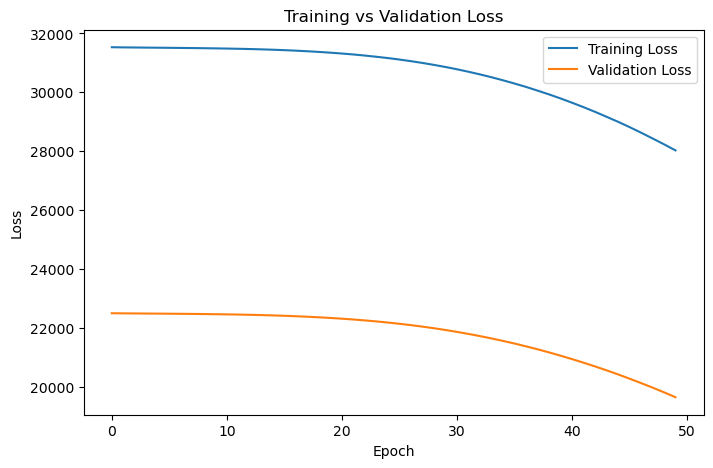

In [9]:
history = model_1_trained.history

train_loss = history['loss']
val_loss = history['val_loss']

plt.figure(figsize=(8,5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
n_cols = X_train.shape[1]

model_2 = Sequential()
model_2.add(Dense(100, activation = 'relu', input_shape = (n_cols, )))
model_2.add(keras.layers.Dropout(0.50))
model_2.add(Dense(10, activation = 'relu'))
model_2.add(Dense(10, activation = 'relu'))
model_2.add(Dense(1))

model_2.summary()

model_2.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics=['mean_squared_error'])

early_stopping_monitor = EarlyStopping(patience = 2)  
model_2_trained = model_2.fit(X_train, y_train, validation_split = 0.2, epochs = 50, callbacks = [early_stopping_monitor])

c:\Users\mansk\anaconda3\envs\tensorflow_conda\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 100)            │         1,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,231 (8.71 KB)

 Trainable params: 2,231 (8.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 31515.6992 - mean_squared_error: 31515.6992 - val_loss: 22469.4688 - val_mean_squared_error: 22469.4688
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 31487.9258 - mean_squared_error: 31487.9258 - val_loss: 22443.0312 - val_mean_squared_error: 22443.0312
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 31449.6484 - mean_squared_error: 31449.6484 - val_loss: 22406.2188 - val_mean_squared_error: 22406.2188
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 31396.2559 - mean_squared_error: 31396.2559 - val_loss: 22354.4160 - val_mean_squared_error: 22354.4160
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 31318.9961 - mean_squared_error: 31318.9961 - val_loss: 22281.7754 - val_mean_squared_error: 22281.7754
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 31216.2656 - mean_squared_error: 31216.2656 - val_loss: 22180.5137 - val_mean_squared_error: 22180.5137
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━

* Epok = När hela träningsdatan har passerat genom nätverket en gång.
* Batch = En delmängd av träningsdatan. Vikter uppdateras efter varje batch. 
* loss/val_loss: Modellens genomsnittliga fel på tränings- respektive valideringsdata. 
* Överanpassning: loss går nedåt, val_loss går uppåt. loss och val_loss ska vara när varandra.
* Underanpassning: loss och val_loss är hög.

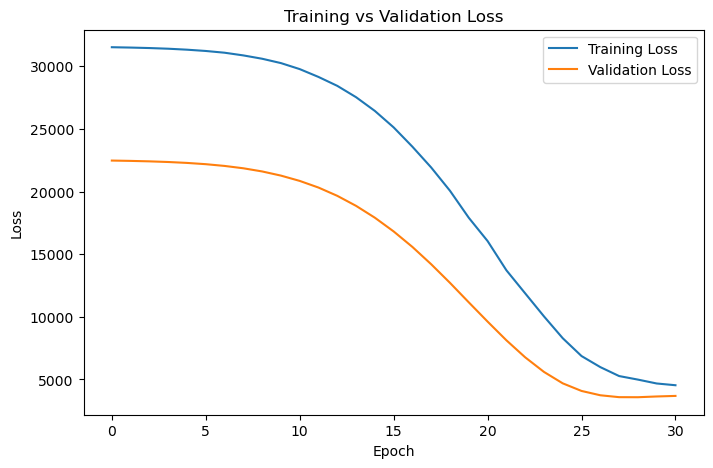

In [14]:
history = model_2_trained.history

train_loss = history['loss']
val_loss = history['val_loss']

plt.figure(figsize=(8,5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

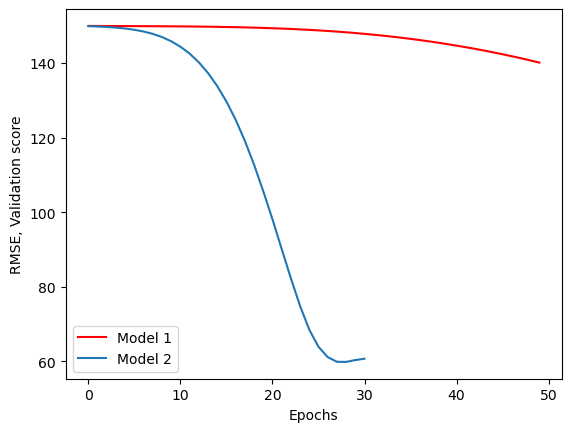

In [15]:
plt.plot(np.sqrt(model_1_trained.history['val_loss']), 'r', label='Model 1')
plt.plot(np.sqrt(model_2_trained.history['val_loss']), label='Model 2')
plt.xlabel('Epochs')
plt.ylabel('RMSE, Validation score')
plt.legend()

#### Models with Scikit-learn

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

In [16]:
random_forest = RandomForestRegressor()
param_grid = { 
    'n_estimators': [10, 50, 100],
    'max_depth' : [1, 2, 5, 10],
}
cv_rf = GridSearchCV(estimator=random_forest, param_grid=param_grid, cv= 5)
cv_rf.fit(X_train, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [1, 2, ...], 'n_estimators': [10, 50, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


OBS Använd inte test för modelljämföelse

In [ ]:
y_pred_m1 = model_1.predict(X_test)
y_pred_m2 = model_2.predict(X_test)
y_pred_lin_reg = lin_reg.predict(X_test)
y_pred_rf = cv_rf.predict(X_test)

In [18]:
print(mean_squared_error(y_pred_m1, y_test))
print(mean_squared_error(y_pred_m2, y_test))
print(mean_squared_error(y_pred_lin_reg, y_test))
print(mean_squared_error(y_pred_rf, y_test))

NameError: name 'y_pred_m1' is not defined

När är neurala nätverk överlägsna?

* Data är högdimensionell (bilder, ljud, text)
* Mönstren är mycket icke-linjära
* Feature engineering är svårt

Men de kräver:

* Mycket data
* Mycket beräkningskraft
* Bra design